In [1]:
pip install mne xmltodict

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import glob
import mne
import xmltodict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint

print("Libraries imported!")


Libraries imported!


In [17]:
# Reading the recording of one patient to get information about the signals 
raw_info = mne.io.read_raw_edf(edf_files[0], preload=False, verbose=False)

duration_sec  = raw_info.times[-1]
duration_hour = duration_sec / 3600
duration_min  = (duration_sec % 3600) / 60

print("=" * 40)
print(f"Patient: {os.path.basename(edf_files[0])}")
print("=" * 40)
print(f"Duration:        {int(duration_hour)}h {int(duration_min)}m")
print(f"Sampling Rate:   {raw_info.info['sfreq']} Hz")
print(f"No. of Channels: {len(raw_info.ch_names)}")
print("=" * 40)

Patient: mesa-sleep-0001.edf
Duration:        11h 59m
Sampling Rate:   256.0 Hz
No. of Channels: 27


In [18]:
# Displaying the exisiting channels 
raw_sample = mne.io.read_raw_edf(edf_files[0], preload=False, verbose=False)

print("All Channels:")
for i, ch in enumerate(raw_sample.ch_names):
    print(f"{i+1}. {ch}")

All Channels:
1. EKG
2. EOG-L
3. EOG-R
4. EMG
5. EEG1
6. EEG2
7. EEG3
8. Pres
9. Flow
10. Snore
11. Thor
12. Abdo
13. Leg
14. Therm
15. Pos
16. EKG_Off
17. EOG-L_Off
18. EOG-R_Off
19. EMG_Off
20. EEG1_Off
21. EEG2_Off
22. EEG3_Off
23. Pleth
24. OxStatus
25. SpO2
26. HR
27. DHR


In [4]:
# Loading the data "EDF Files"

folder_path = r'C:\Users\malak\Downloads\SIGNALS\Dataset'
edf_files   = sorted(glob.glob(os.path.join(folder_path, '*.edf')))
print(f"✅ No. of patients: {len(edf_files)}")

# Channel selsection
channels          = ['EOG-R']
sampling_rate     = 256
samples_per_epoch = sampling_rate * 30  # Each Epoch is 30 sec

# Stage Mapping "Assigning a no. to each sleep stage"
stage_mapping = {
    'Wake|0'          : 0,
    'Stage 1 sleep|1' : 1,
    'Stage 2 sleep|2' : 2,
    'Stage 3 sleep|3' : 3,
    'REM sleep|5'     : 4
}

X_all = []
y_all = []

for edf_file in edf_files:
    xml_file = edf_file.replace('.edf', '-nsrr.xml')
    
    if not os.path.exists(xml_file):
        print(f" No Xml {os.path.basename(edf_file)}")
        continue
    
    print(f"🔄 {os.path.basename(edf_file)}")
    
    # Reading EDF files
    raw = mne.io.read_raw_edf(edf_file, preload=True, verbose=False)
    
    # Reading XML files
    with open(xml_file, 'r') as f:
        xml_data = xmltodict.parse(f.read())
    events = xml_data['PSGAnnotation']['ScoredEvents']['ScoredEvent']
    
    # Sleep Stages Events Filtering
    sleep_stages = []
    for event in events:
        event_concept = str(event.get('EventConcept', ''))
        if 'sleep' in event_concept.lower() or 'wake' in event_concept.lower():
            sleep_stages.append({
                'stage'   : event_concept,
                'start'   : float(event['Start']),
                'duration': float(event['Duration'])
            })
    
    df_stages = pd.DataFrame(sleep_stages)
    df_stages['label'] = df_stages['stage'].map(stage_mapping)
    df_stages = df_stages.dropna(subset=['label'])
    
    # Dividing Signals to Epochs "Segmentation"
    for _, row in df_stages.iterrows():
        n_epochs = int(row['duration'] // 30)
        for i in range(n_epochs):
            start_sample = int((row['start'] + i * 30) * sampling_rate)
            end_sample   = start_sample + samples_per_epoch
            try:
                epoch_data = raw.get_data(
                    picks=channels,
                    start=start_sample,
                    stop=end_sample
                )
                if epoch_data.shape[1] == samples_per_epoch:
                    X_all.append(epoch_data)
                    y_all.append(int(row['label']))
            except:
                continue
    
    print(f"✅ Total epochs so far: {len(X_all)}")

X_all = np.array(X_all)
y_all = np.array(y_all)

print(f"\n X shape: {X_all.shape}")
print(f" y shape: {y_all.shape}")


✅ No. of patients: 10
🔄 mesa-sleep-0001.edf
✅ Total epochs so far: 1439
🔄 mesa-sleep-0002.edf
✅ Total epochs so far: 2758
🔄 mesa-sleep-0006.edf
✅ Total epochs so far: 3837
🔄 mesa-sleep-0010.edf
✅ Total epochs so far: 5036
🔄 mesa-sleep-0012.edf
✅ Total epochs so far: 6463
🔄 mesa-sleep-0014.edf
✅ Total epochs so far: 8142
🔄 mesa-sleep-0016.edf
✅ Total epochs so far: 9341
🔄 mesa-sleep-0021.edf
✅ Total epochs so far: 10420
🔄 mesa-sleep-0027.edf
✅ Total epochs so far: 11619
🔄 mesa-sleep-0028.edf
✅ Total epochs so far: 12758

 X shape: (12758, 1, 7680)
 y shape: (12758,)


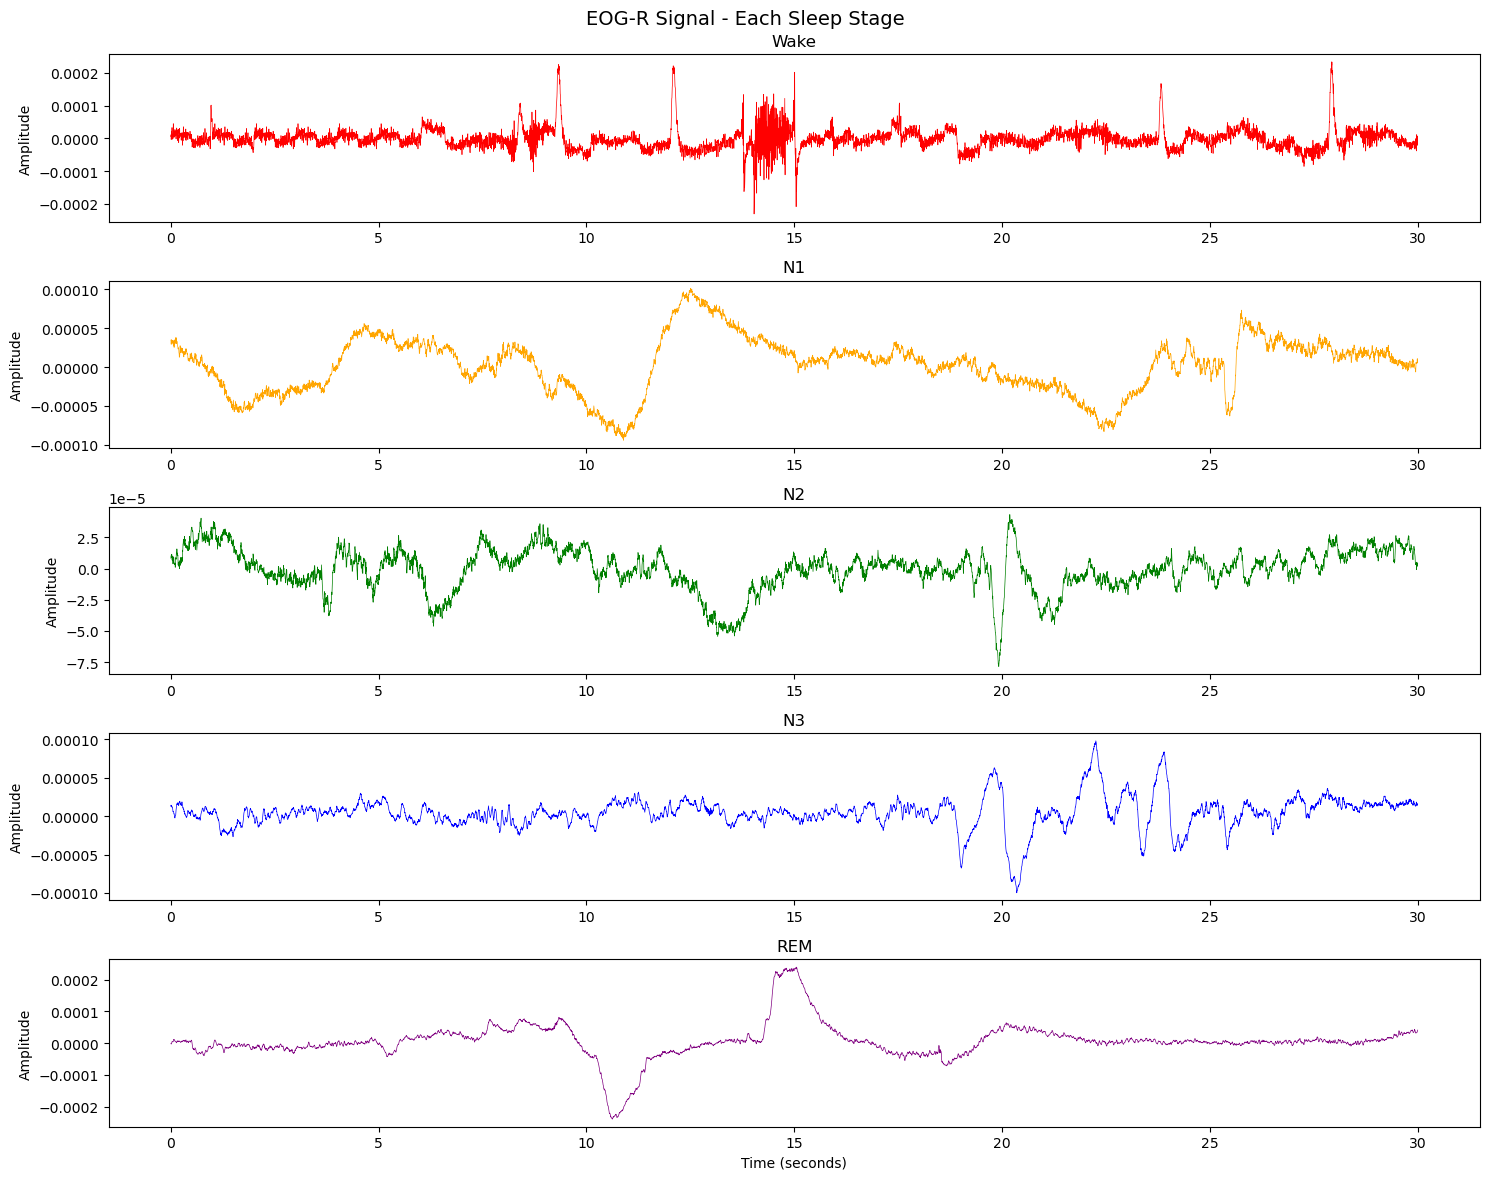

In [6]:
#  Visualizing an epoch of the signal for each sleep stage
stage_names = {0:'Wake', 1:'N1', 2:'N2', 3:'N3', 4:'REM'}
colors      = {0:'red', 1:'orange', 2:'green', 3:'blue', 4:'purple'}

fig, axes = plt.subplots(5, 1, figsize=(15, 12))

for stage in range(5):
    idx = np.where(y_all == stage)[0]
    if len(idx) > 0:
        epoch = X_all[idx[0], 0, :]
        time  = np.linspace(0, 30, samples_per_epoch)
        axes[stage].plot(time, epoch,
                        color=colors[stage],
                        linewidth=0.5)
        axes[stage].set_title(f'{stage_names[stage]}')
        axes[stage].set_ylabel('Amplitude')
    else:
        axes[stage].set_title(f'{stage_names[stage]} - No data')

axes[-1].set_xlabel('Time (seconds)')
plt.suptitle('EOG-R Signal - Each Sleep Stage', fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
# Normalization

scaler    = StandardScaler()
X_reshaped = X_all.reshape(-1, 1)
X_normalized = scaler.fit_transform(X_reshaped).reshape(X_all.shape)
print("✅ Normalization Done!")


✅ Normalization Done!


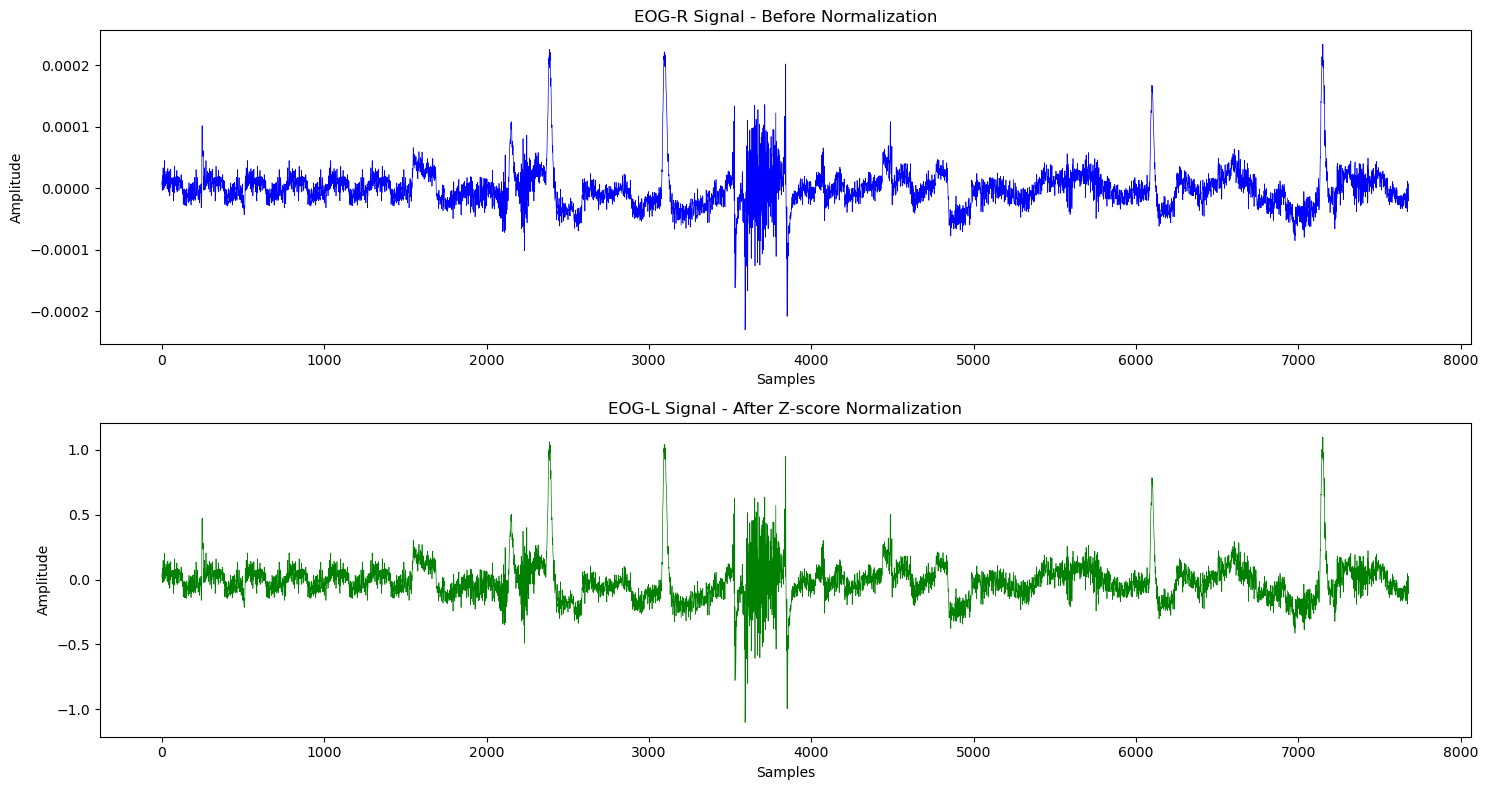

Before - Min: -0.000231  Max: 0.000233
After  - Min: -1.10  Max: 1.10


In [8]:
# Visualizing Data
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Before Normalization
axes[0].plot(X_all[0, 0, :], color='blue', linewidth=0.5)
axes[0].set_title('EOG-R Signal - Before Normalization')
axes[0].set_xlabel('Samples')
axes[0].set_ylabel('Amplitude')

# After Normalization
axes[1].plot(X_normalized[0, 0, :], color='green', linewidth=0.5)
axes[1].set_title('EOG-L Signal - After Z-score Normalization')
axes[1].set_xlabel('Samples')
axes[1].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

print(f"Before - Min: {X_all[0,0,:].min():.6f}  Max: {X_all[0,0,:].max():.6f}")
print(f"After  - Min: {X_normalized[0,0,:].min():.2f}  Max: {X_normalized[0,0,:].max():.2f}")

In [9]:
# Splitting tha data into 80% train, 10% validation, 10% test "Random Split" n

X_train, X_temp, y_train, y_temp = train_test_split(
    X_normalized, y_all,
    test_size=0.2, random_state=42, stratify=y_all
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5, random_state=42, stratify=y_temp
)

# Reshape into (Epochs, Samples per epoch, channels)
X_train = X_train.reshape(-1, samples_per_epoch, 1)
X_val   = X_val.reshape(-1, samples_per_epoch, 1)
X_test  = X_test.reshape(-1, samples_per_epoch, 1)

print(f"✅ Train: {X_train.shape}")
print(f"✅ Val:   {X_val.shape}")
print(f"✅ Test:  {X_test.shape}")

print("\nClasses distribution before SMOTE:")
stage_names = {0:'Wake', 1:'N1', 2:'N2', 3:'N3', 4:'REM'}
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {stage_names[u]}: {c}")

✅ Train: (10206, 7680, 1)
✅ Val:   (1276, 7680, 1)
✅ Test:  (1276, 7680, 1)

Classes distribution before SMOTE:
  Wake: 4455
  N1: 754
  N2: 3293
  N3: 695
  REM: 1009


In [10]:
# Smote training data to balance the classes
X_flat = X_train.reshape(len(X_train), -1)

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_flat, y_train)

# Return shape
X_train = X_resampled.reshape(-1, samples_per_epoch, 1)
y_train = y_resampled

print(f"✅ Train: {X_train.shape}")
print(f"✅ Val:   {X_val.shape}")
print(f"✅ Test:  {X_test.shape}")
print("\nClasses distribution after SMOTE:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {stage_names[u]}: {c}")

✅ Train: (22275, 7680, 1)
✅ Val:   (1276, 7680, 1)
✅ Test:  (1276, 7680, 1)

Classes distribution after SMOTE:
  Wake: 4455
  N1: 4455
  N2: 4455
  N3: 4455
  REM: 4455


In [11]:
# Class Weights

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

print("✅ Class Weights:")
for cls, weight in class_weight_dict.items():
    print(f"  {stage_names[cls]}: {weight:.4f}")

✅ Class Weights:
  Wake: 1.0000
  N1: 1.0000
  N2: 1.0000
  N3: 1.0000
  REM: 1.0000


In [12]:
# Building the Model
model = Sequential([
    Conv1D(32, kernel_size=50, activation='relu',
           input_shape=(samples_per_epoch, 1)),
    MaxPooling1D(pool_size=8),
    Dropout(0.3),

    Conv1D(64, kernel_size=25, activation='relu'),
    MaxPooling1D(pool_size=8),
    Dropout(0.3),

    LSTM(32, return_sequences=False),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dense(5, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=0.0001,
        weight_decay=0.001
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


C:\Users\MALAK\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 7631, 32)       │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 953, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 953, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 929, 64)        │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 116, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 116, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,533 (259.89 KB)

 Trainable params: 66,533 (259.89 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Training

checkpoint = ModelCheckpoint(
    'best_model_eog-R.keras',
    monitor='val_accuracy',
    save_best_only=True
)

history = model.fit(
    X_train, y_train,
    epochs=80,
    batch_size=64,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict,
    callbacks=[checkpoint],
    verbose=1
)

print("✅ Training Done!")

Epoch 1/80
349/349 ━━━━━━━━━━━━━━━━━━━━ 114s 310ms/step - accuracy: 0.3292 - loss: 1.4446 - val_accuracy: 0.4757 - val_loss: 1.0989
Epoch 2/80
349/349 ━━━━━━━━━━━━━━━━━━━━ 109s 313ms/step - accuracy: 0.4210 - loss: 1.2703 - val_accuracy: 0.5039 - val_loss: 1.0552
Epoch 3/80
349/349 ━━━━━━━━━━━━━━━━━━━━ 109s 311ms/step - accuracy: 0.5025 - loss: 1.1539 - val_accuracy: 0.5039 - val_loss: 1.0432
Epoch 4/80
349/349 ━━━━━━━━━━━━━━━━━━━━ 111s 317ms/step - accuracy: 0.5369 - loss: 1.0759 - val_accuracy: 0.5204 - val_loss: 0.9746
Epoch 5/80
349/349 ━━━━━━━━━━━━━━━━━━━━ 110s 316ms/step - accuracy: 0.5659 - loss: 1.0085 - val_accuracy: 0.5266 - val_loss: 0.9136
Epoch 6/80
349/349 ━━━━━━━━━━━━━━━━━━━━ 111s 317ms/step - accuracy: 0.5887 - loss: 0.9470 - val_accuracy: 0.5745 - val_loss: 0.9148
Epoch 7/80
349/349 ━━━━━━━━━━━━━━━━━━━━ 110s 315ms/step - accuracy: 0.6177 - loss: 0.8971 - val_accuracy: 0.6238 - val_loss: 0.8350
Epoch 8/80
349/349 ━━━━━━━━━━━━━━━━━━━━ 110s 314ms/step - accuracy: 0.6442 -

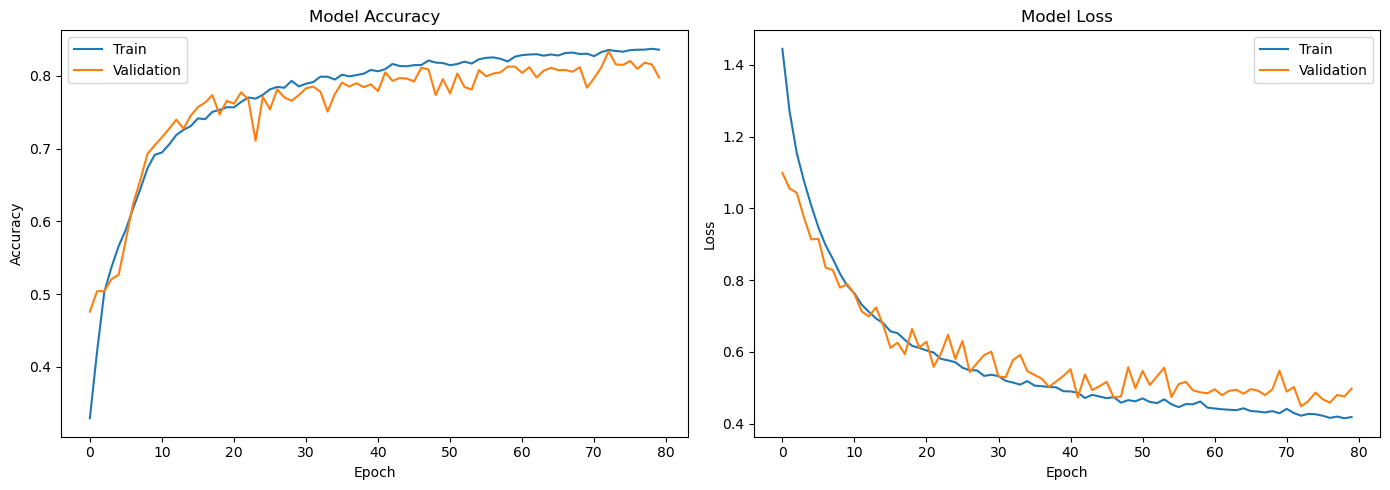

In [14]:
# Evaluation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step
Classification Report:
              precision    recall  f1-score   support

        Wake       0.99      0.92      0.96       557
          N1       0.39      0.61      0.47        94
          N2       0.87      0.76      0.81       412
          N3       0.60      0.90      0.72        87
         REM       0.88      0.83      0.86       126

    accuracy                           0.84      1276
   macro avg       0.75      0.81      0.76      1276
weighted avg       0.87      0.84      0.85      1276



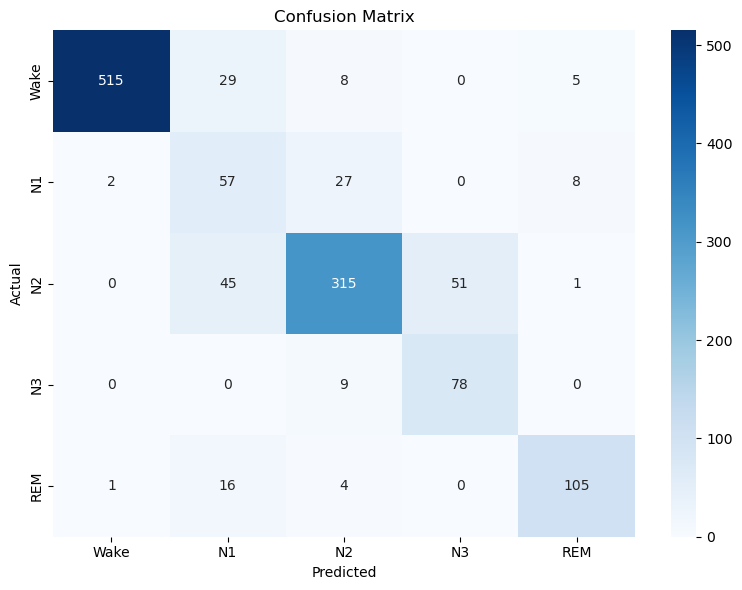

In [15]:
# Results
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Best model
best_model = tf.keras.models.load_model('best_model_eog-R.keras')

# Prediction on Test Data
y_pred = best_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Classification Report
stage_names = ['Wake', 'N1', 'N2', 'N3', 'REM']
print("Classification Report:")
print(classification_report(y_test, y_pred_classes,
                            target_names=stage_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=stage_names,
            yticklabels=stage_names,
            cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()